# 03 - Modeling

Binary classification of network traffic (BENIGN vs DDoS) using the preprocessed CIC-DDoS2019 dataset.

Models trained:
- **Random Forest** — ensemble tree model, handles class imbalance well with `class_weight='balanced'`
- **Linear SVM** — fast linear classifier, scales well to high-dimensional data

Evaluation metrics: accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix.

In [21]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

sns.set_style("whitegrid")
%matplotlib inline

In [23]:
# Configuration
DATA_PATH = "../data/processed/ddos_basic_preprocessed.csv"
MODELS_DIR = "../models"
FIGURES_DIR = "../reports/figures"
TEST_SIZE = 0.2
RANDOM_STATE = 42

## Load Data

In [24]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df["target"].value_counts())
print(f"\nClass ratio (DDoS/BENIGN): {df['target'].value_counts()[1] / df['target'].value_counts()[0]:.1f}:1")
df.head()

Shape: (15603, 82)

Target distribution:
target
1    13599
0     2004
Name: count, dtype: int64

Class ratio (DDoS/BENIGN): 6.8:1


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound,target
0,60675,80,6,5220876,12,9,1928.0,4290.0,509.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,1,1
1,60676,80,6,12644252,5,2,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,1,1
2,443,50458,6,3,2,0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,1,0
3,443,50465,6,3,2,0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,1,0
4,0,0,0,114329232,52,0,0.0,0.0,0.0,0.0,...,7.416667,2.466441,15.0,6.0,9527428.0,248706.681286,9950741.0,9092248.0,0,0


## Prepare Features and Split

In [25]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train: {len(X_train):,} samples")
print(f"Test:  {len(X_test):,} samples")
print(f"\nTrain target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())

Train: 12,482 samples
Test:  3,121 samples

Train target distribution:
target
1    10879
0     1603
Name: count, dtype: int64

Test target distribution:
target
1    2720
0     401
Name: count, dtype: int64


In [26]:
# Scale features (required for SVM, harmless for RF)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features scaled. Mean (first 3): {X_train_scaled[:, :3].mean(axis=0).round(4)}")

Features scaled. Mean (first 3): [-0.  0. -0.]


## Model 1: Random Forest

`class_weight='balanced'` adjusts weights inversely proportional to class frequencies — compensates for the 87%/13% class imbalance.

In [27]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


In [28]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest — Test Set Results ===")
print(classification_report(y_test, y_pred_rf, target_names=["BENIGN", "DDoS"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

=== Random Forest — Test Set Results ===
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00       401
        DDoS       1.00      1.00      1.00      2720

    accuracy                           1.00      3121
   macro avg       1.00      1.00      1.00      3121
weighted avg       1.00      1.00      1.00      3121

ROC-AUC: 1.0000


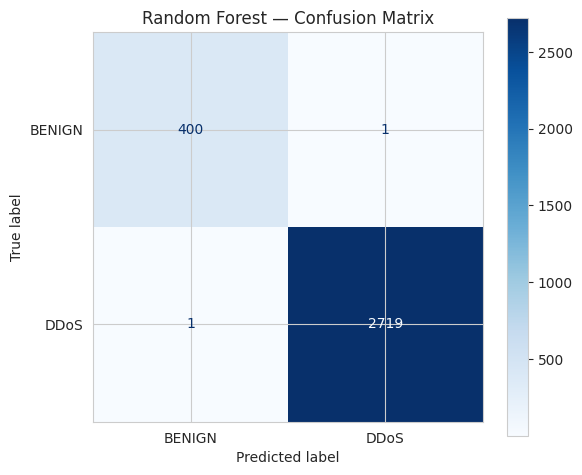

In [29]:
# Confusion matrix — Random Forest
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=["BENIGN", "DDoS"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rf_confusion_matrix.png", dpi=150)
plt.show()

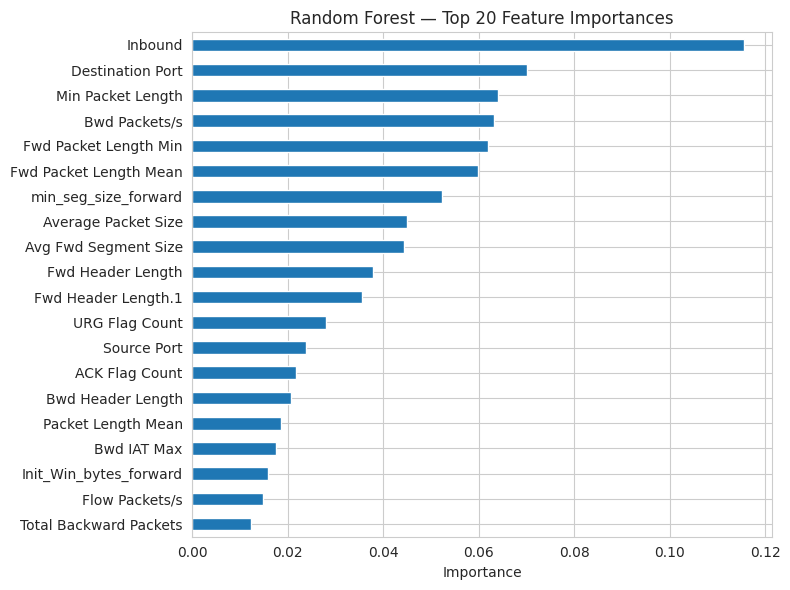

In [30]:
# Feature importance — top 20
importances = pd.Series(rf.feature_importances_, index=X.columns)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Random Forest — Top 20 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rf_feature_importance.png", dpi=150)
plt.show()

## Model 2: SVM (Linear)

`LinearSVC` — linear support vector classifier, efficient for large feature spaces. `CalibratedClassifierCV` wraps it to produce probability scores needed for ROC-AUC.

In [31]:
svm_base = LinearSVC(
    class_weight="balanced",
    max_iter=10000,
    random_state=RANDOM_STATE,
)
svm = CalibratedClassifierCV(svm_base, cv=3)
svm.fit(X_train_scaled, y_train)
print("Linear SVM trained.")

Linear SVM trained.


In [32]:
y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

print("=== Linear SVM — Test Set Results ===")
print(classification_report(y_test, y_pred_svm, target_names=["BENIGN", "DDoS"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_svm):.4f}")

=== Linear SVM — Test Set Results ===
              precision    recall  f1-score   support

      BENIGN       0.95      0.94      0.95       401
        DDoS       0.99      0.99      0.99      2720

    accuracy                           0.99      3121
   macro avg       0.97      0.97      0.97      3121
weighted avg       0.99      0.99      0.99      3121

ROC-AUC: 0.9983


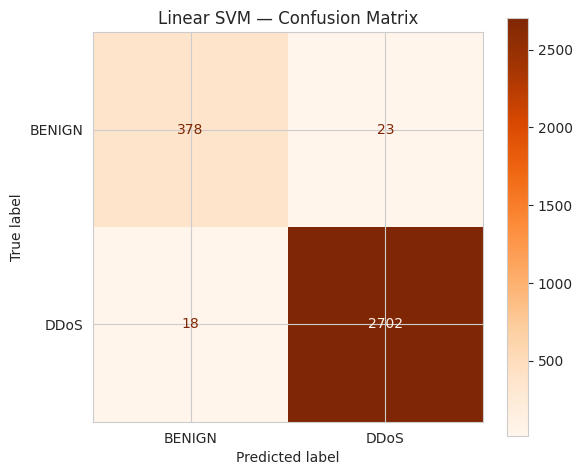

In [33]:
# Confusion matrix — SVM
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    display_labels=["BENIGN", "DDoS"],
    cmap="Oranges",
    ax=ax
)
ax.set_title("Linear SVM — Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/svm_confusion_matrix.png", dpi=150)
plt.show()

## Model Comparison

In [34]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def metrics_row(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    metrics_row("Random Forest", y_test, y_pred_rf, y_proba_rf),
    metrics_row("Linear SVM",    y_test, y_pred_svm, y_proba_svm),
])

print(results.to_string(index=False))

        Model  Accuracy  Precision   Recall       F1  ROC-AUC
Random Forest  0.999359   0.999632 0.999632 0.999632 0.999997
   Linear SVM  0.986863   0.991560 0.993382 0.992470 0.998292


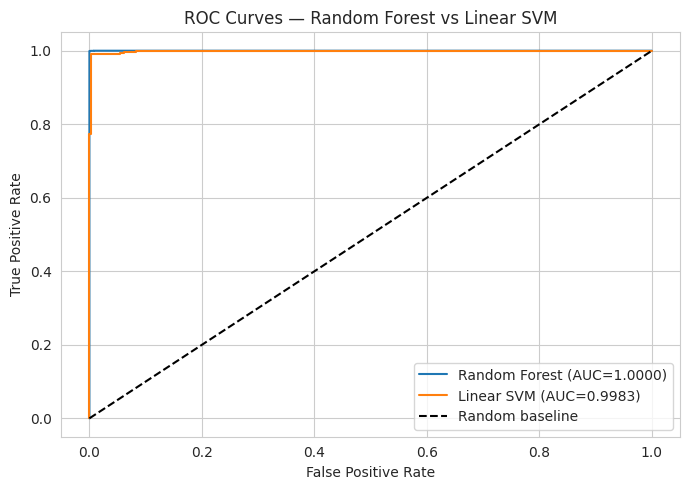

In [35]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))

for name, proba in [("Random Forest", y_proba_rf), ("Linear SVM", y_proba_svm)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Random Forest vs Linear SVM")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/roc_curves.png", dpi=150)
plt.show()

## Cross-Validation (Stratified K-Fold, k=5)

Walidacja krzyżowa na zbiorze treningowym — 5 podziałów z zachowaniem proporcji klas (`StratifiedKFold`). Pozwala ocenić stabilność modelu niezależnie od jednego konkretnego podziału train/test.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1"]

cv_rf = cross_validate(
    RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    X_train, y_train,
    cv=skf, scoring=scoring,
)

cv_svm = cross_validate(
    CalibratedClassifierCV(LinearSVC(class_weight="balanced", max_iter=10000, random_state=RANDOM_STATE), cv=3),
    X_train_scaled, y_train,
    cv=skf, scoring=scoring,
)

print("=== Cross-Validation Results (5-fold, zbiór treningowy) ===\n")
for name, cv in [("Random Forest", cv_rf), ("Linear SVM", cv_svm)]:
    print(f"{name}:")
    for metric in scoring:
        scores = cv[f"test_{metric}"]
        print(f"  {metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}")
    print()

## Save Models

In [36]:
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(rf,     f"{MODELS_DIR}/random_forest.joblib")
joblib.dump(svm,    f"{MODELS_DIR}/linear_svm.joblib")
joblib.dump(scaler, f"{MODELS_DIR}/scaler.joblib")

print("Saved:")
print(f"  {MODELS_DIR}/random_forest.joblib")
print(f"  {MODELS_DIR}/linear_svm.joblib")
print(f"  {MODELS_DIR}/scaler.joblib")

Saved:
  ../models/random_forest.joblib
  ../models/linear_svm.joblib
  ../models/scaler.joblib
